<a href="https://colab.research.google.com/github/fernandabomtorin16/jogo_ottelo/blob/main/IAD_011_RL_Ex4_Othello_TD_Aprox_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import copy
import urllib.request
import json
import copy

#1 - Métodos Aproximados e o jogo de Othello


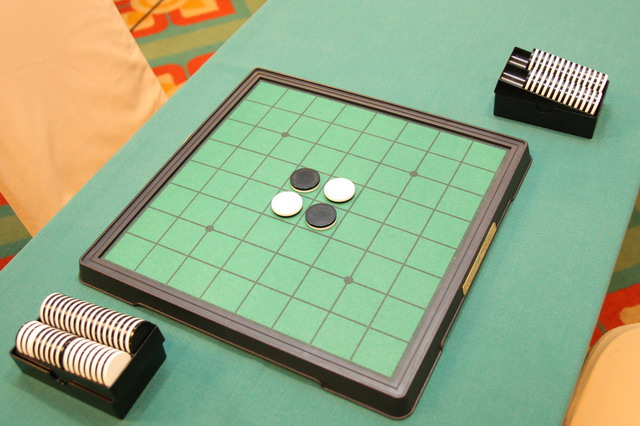

# 1.1 O jogo Othello
O jogo Othello, ou Reversi, é um jogo de tabuleiro no qual jogadores se alternam posicionando fichas sobre um quadriculado.

As fichas possuem duas faces de cores diferentes (geralmente "Brancas" e "Negras"). A cada jogador corresponde uma cor.
No posicionamento de uma ficha, todas as fichas de cor oposta em linha nas quatro direções principais e quatro diagonais, *limitadas por outra ficha da cor do jogador atual* são "capturadas", ou seja, são viradas para a cor do jogador que posicionou a ficha.

Um jogador só pode posicionar uma ficha se puder capturar ao menos uma peça do adversário.
Caso contrário a sua jogada é "pulada".
O jogo acaba quando nenhum jogador pode fazer mais jogadas.
O vencedor é o jogador com a maior quantidade de fichas de sua cor no tabuleiro.

A posição inicial é a exibida na figura acima, com o quadrado central ocupado por duas fichas brancas e duas fichas negras em diagonais opostas.

O jogador com as fichas negras joga primeiro.

A classe ```Othello``` definida a seguir faz uma implementação das regras do jogo:

In [2]:
class Othello():

  direcoes_captura =\
   [(-1, -1), (-1, 0), (-1, +1), (0, -1), (0, +1), (+1, -1), (+1, 0), (+1, +1)]

  def __init__(self, outro = None):
    if outro:  # Construtor de cópia
      self._cols = outro._cols
      self._lins = outro._lins
      self._jogador_atual = outro._jogador_atual
      self._tabuleiro = copy.deepcopy(outro._tabuleiro)
      self._terminou = outro._terminou
      self._placar = list(outro._placar)
      # Normalmente essa informação vai ser descartada, então não é copiada
      self._capturas = None
      self._jogadas_legais = None
    else: # Novo jogo
      self._cols = 8
      self._lins = 8
      self._reset()

  def _reset(self):
    self._jogador_atual = 1
    self._tabuleiro = [\
      [ 0, 0, 0, 0, 0, 0, 0, 0],\
      [ 0, 0, 0, 0, 0, 0, 0, 0],\
      [ 0, 0, 0, 0, 0, 0, 0, 0],\
      [ 0, 0, 0,-1, 1, 0, 0, 0],\
      [ 0, 0, 0, 1,-1, 0, 0, 0],\
      [ 0, 0, 0, 0, 0, 0, 0, 0],\
      [ 0, 0, 0, 0, 0, 0, 0, 0],\
      [ 0, 0, 0, 0, 0, 0, 0, 0]\
    ]
    self._terminou = False
    self._placar = [2,2]
    self._capturas = None
    self._jogadas_legais = None

  def dim(self):
    return (self._cols, self._lins)

  def jogador_atual(self):
    self._checa_estado_atualizado()
    return self._jogador_atual

  # Retorna o conteúdo do tabuleiro em uma posicao
  def posicao(self, posicao):
    return self._tabuleiro[posicao[0]][posicao[1]]

  # Retorna uma cópia do tabuleiro
  def tabuleiro(self):
    return np.array(self._tabuleiro, dtype=np.int8)

  def placar(self, jogador):
    return self._placar[(1+jogador)//2]

  # O estado só é completamente computado caso seja necessário
  # pois algumas jogadas podem ser descartadas
  def _checa_estado_atualizado(self):
    if self._jogadas_legais is None:
      self._atualiza_capturas_e_jogadas_legais()
      # Verifica se jogador atual tem jogadas disponíveis
      if len(self._jogadas_legais)==0:
        # Troca de jogador
        self._jogador_atual = -self._jogador_atual
        self._atualiza_capturas_e_jogadas_legais()
        # Jogo terminou?
        if len(self._jogadas_legais)==0:
          self._terminou = True

  # Verdadeiro se o jogo terminou, falso caso contrário
  def terminou(self):
    self._checa_estado_atualizado()
    return self._terminou

  # Verifica se uma determinada posicao é valida
  def posicao_valida(self, posicao):
    return posicao[0]>=0 and posicao[0]<self._lins and posicao[1]>=0 and posicao[1]<self._cols

  # Retorna a lista de capturas em uma determinada direção
  def _lista_de_capturas(self, posicao, direcao, jogador):
    posicoes = []
    lin = posicao[0] + direcao[0]
    col = posicao[1] + direcao[1]
    while self.posicao_valida((lin, col)) and self.posicao((lin, col)) == -jogador:
      posicoes.append((lin, col))
      lin += direcao[0]
      col += direcao[1]
    return posicoes if self.posicao_valida((lin, col)) and self.posicao((lin, col)) == jogador else []

  # Atualiza a lista de jogadas legais
  def _atualiza_capturas_e_jogadas_legais(self):
    self._jogadas_legais = set()
    self._capturas = []
    for i in range(self._lins):
      self._capturas.append([])
      for j in range(self._cols):
        cap_possivel = False
        if self._tabuleiro[i][j]==0:
          self._capturas[-1].append([])
          for d in Othello.direcoes_captura:
            self._capturas[-1][-1].append(self._lista_de_capturas((i, j), d, self._jogador_atual)            )
            cap_possivel = cap_possivel or len(self._capturas[-1][-1][-1])>0
        else:
          self._capturas[-1].append([[]]*len(Othello.direcoes_captura))
        if cap_possivel:
          self._jogadas_legais.add((i, j))

  # Verifica se uma jogada é legal
  def jogada_legal(self, jogada):
    self._checa_estado_atualizado()
    return jogada in self._jogadas_legais

  # Retorna o conjunto de jogadas legais
  def jogadas_legais(self):
    self._checa_estado_atualizado()
    return list(self._jogadas_legais)

  # Processa a captura de peças após uma jogada com base em listas de capturas
  def _processa_captura_pecas(self, listas_de_capturas):
    for lista_capturas in listas_de_capturas:
      for pi, pj in lista_capturas:
          self._tabuleiro[pi][pj] = self._jogador_atual
          self._placar[(1+self._jogador_atual)//2] += 1
          self._placar[(1-self._jogador_atual)//2] -= 1

  # Aplica uma jogada. Precisa de uma lista de capturas a ser executada
  def _aplica_jogada(self, jogada, listas_de_capturas):
    self._tabuleiro[jogada[0]][jogada[1]] = self._jogador_atual
    self._placar[(1+self._jogador_atual)//2] += 1
    self._processa_captura_pecas(listas_de_capturas)
    self._jogador_atual = -self._jogador_atual
    self._atualiza_capturas_e_jogadas_legais()
    # Verifica se jogador atual tem jogadas disponíveis
    if len(self._jogadas_legais)==0:
        # Troca de jogador
        self._jogador_atual = -self._jogador_atual
        self._atualiza_capturas_e_jogadas_legais()
        # Jogo terminou?
        if len(self._jogadas_legais)==0:
          self._terminou = True

  # Aplica jogada
  # Retorna um *novo jogo*
  def joga(self, jogada):
    self._checa_estado_atualizado()
    if self._terminou:
      raise RuntimeError("Jogo encerrado")
    if not self.jogada_legal(jogada):
      raise RuntimeError("Jogada Ilegal")
    # Clona jogo atual
    novo_jogo = Othello(self)
    novo_jogo._aplica_jogada(jogada, self._capturas[jogada[0]][jogada[1]])
    # O jogo é retornado em um estado semi-computado
    return novo_jogo


Os métodos relevantes são:

> ```__init__(self, outro = None)```: Constrói um novo jogo. Caso o método receba outro jogo no parâmetro ```outro```, é criada uma cópia deste jogo.

> ```jogador_atual(self)```: Retorna o índice do jogador atual. Os índices possíveis são -1 e 1. O jogador inicial é o jogador de índice 1. Este valor deve ser desconsiderado caso o jogo tenha acabado. Vide método ```terminou()``` adiante.

> ```posicao(self, posicao)```: Retorna o conteúdo do tabuleiro em uma determinada posição. Posição é uma tupla com os índices da linha e coluna do tabuleiro (baseados em zero). O valor retornado é o índice do jogador que possui a ficha na posição indicada ou zero se a posição está vazia.

> ```dim(self)```: Retona as dimensões do tabuleiro. Esta implementação retorna sempre $8 \times 8$.

> ```tabuleiro(self)```: Retorna um *array* numpy com o conteúdo do tabuleiro.

> ```placar(self, jogador)```: Retorna o placar do jogador passado no parâmetro ```jogador``` (este valor deve ser -1 ou 1).

> ```terminou(self)```: Retorna ```True``` caso o jogo tenha acabado, ```False``` caso contrário. Nota: Caso o jogo tenha terminado, o valor retornado pelo método ```jogador_atual()``` deve ser desconsiderado.

> ```jogada_legal(self, jogada)```: Retorna ```True``` caso o jogador atual possa jogar uma ficha na posição indicada por ```jogada```, ```False``` caso contrário. Jogadas são tuplas com linha e coluna.

> ```jogadas_legais(self)```: Retorna uma sequência com a lista de todas as jogadas legais para o jogador atual.

> ```joga(self, jogada)```: Retorna o resultado da jogada descrita no parâmetro ```jogada```. Este parâmetro é uma tupla com a linha e coluna onde deve ser colocada a ficha. Note que este método *não* modifica o estado do objeto, mas retorna um *novo* jogo com o resultado da jogada. Assim, se por exemplo a variável ```jogo``` contém o estado *atual* do jogo e a variável ```jogada``` contém a próxima jogada a ser feita, a variável jogo deve ser atualizada da seguinte maneira:
```
jogo = jogo.joga(jogada)
```




O código abaixo implementa uma partida interativa entre dois jogadores humanos.
Teste-o para acostumar-se com as regras do jogo:

In [3]:
def partida_interativa(jogo):
  rows, cols = jogo.dim()

  buttons = [widgets.Button(value = i, description=' ',disabled=False,buttom_style='',layout={'width': '35px', 'height': '35px'}) for i in range(cols*rows)]
  estado = widgets.HBox([widgets.Label(""), widgets.HTML(" ")])
  placar = widgets.VBox([widgets.Label("Placar:"),widgets.HTML(" "), widgets.HTML(" ")])

  def atualiza_jogo(jog):
    for ii in range(cols*rows):
      i = ii//rows
      j = ii % rows
      e = jog.posicao((i, j))
      if e==0:
        buttons[ii].disabled = not jog.jogada_legal((i,j))
      elif e==-1:
        buttons[ii].disabled = True
        buttons[ii].style.button_color = 'white'
      else:
        buttons[ii].disabled = True
        buttons[ii].style.button_color = 'black'
      placar.children[1].value = "<div style='text-align: center;background-color:White; color:Black'>{}</div>".format(jog.placar(-1))
      placar.children[2].value = "<div style='text-align: center;background-color:Black; color:White'>{}</div>".format(jog.placar(1))
    if jog.terminou():
      estado.children[0].value="Jogo terminou"
      estado.children[1].value=""
    else:
      estado.children[0].value="Proximo Jogador: "
      estado.children[1].value="<div style='background-color:Black'>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;</div>" if jog.jogador_atual()>0 else "<div style='background-color:White'>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;</div>"

  def registra_jogada(jogada):
    nonlocal jogo
    jogo = jogo.joga(jogada)
    atualiza_jogo(jogo)

  for i, b in enumerate(buttons):
    b.on_click((lambda x: lambda b: registra_jogada(x))((i//rows, i%cols)))
  board = widgets.GridBox(buttons, layout=widgets.Layout(grid_template_columns="repeat("+str(cols)+", 40px)"))

  display(widgets.VBox([widgets.HBox([board, placar]),estado]))
  atualiza_jogo(jogo)

In [4]:
partida_interativa(Othello())

Podemos criar um jogador puramente aleatório para o Othello:

In [5]:
class JogadorAleatorio():
  def __init__(self):
    pass

  def nova_partida(self, jogo, jogador):
    pass

  def escolhe_jogada(self, jogo):
    jogadas_possiveis = jogo.jogadas_legais()
    return jogadas_possiveis[np.random.choice(len(jogadas_possiveis))]

  def informa_propria_jogada(self, tabuleiro_antes, jogada, tabuleiro_depois):
    pass

  def informa_jogada_oponente(self, tabuleiro_antes, jogada, tabuleiro_depois):
    pass

  def informa_fim(self, jogo_final):
    pass

O método relevante é:


> ```escolhe_jogada(self, jogo)```: Retorna a próxima jogada do jogador. O parâmetro ```jogo``` é um objeto da classe ```Othello``` com o estado da partida. Note que este jogador simplesmente escolhe aleatoriamente uma dentres as jogadas possíveis.

Esta classe define também os métodos:

> ```nova_partida(self, jogo, jogador)```: Notifica o jogador do início de uma nova partida. O parâmetro ```jogo``` contém o estado inicial e o parâmetro ```jogador``` o número (-1 ou 1) do jogador que este objeto irá representar.

> ```informa_propria_jogada(self, tabuleiro_antes, jogada, tabuleiro_depois)```: Notifica o jogador do resultado de uma jogada feita pelo jogador que ele representa. O parâmetro ```tabuleiro_antes``` contém um objeto da classe ```Othello``` com o estado do jogo *antes* da jogada, o parâmetro ```jogada``` contém a jogada feita e o parâmetro ```tabuleiro_depois``` contém o estado do tabuleiro *depois* da jogada.

> ```informa_jogada_oponente(self, tabuleiro_antes, jogada, tabuleiro_depois)```: Notifica o jogador do resultado de uma jogada feita pelo jogador oponente. O parâmetro ```tabuleiro_antes``` contém um objeto da classe ```Othello``` com o estado do jogo *antes* da jogada, o parâmetro ```jogada``` contém a jogada feita e o parâmetro ```tabuleiro_depois``` contém o estado do tabuleiro *depois* da jogada.

> ```informa_fim(self, jogo_final)```: Notifica o jogador do término do jogo.
O parâmetro ```jogo_final``` contém o estado do jogo ao final da partida.

Note que estes métodos não fazem nada nesta classe.
Como você provavelmente está antecipando, eles serão usados em outras classes para aprendizagem por reforço.

O método ```simula_partida``` simula uma partida entre dois jogadores controlados por computador:

In [6]:
def simula_partida(jogo, jogador1, jogador2):
  jogador1.nova_partida(jogo, 1)
  jogador2.nova_partida(jogo, -1)
  jogadores = {1: jogador1, -1: jogador2}
  while not jogo.terminou():
    jogador_atual = jogadores[jogo.jogador_atual()]
    oponente = jogadores[-jogo.jogador_atual()]
    jogada = jogador_atual.escolhe_jogada(jogo)
    jogo_depois = jogo.joga(jogada)
    jogador_atual.informa_propria_jogada(jogo, jogada, jogo_depois)
    oponente.informa_jogada_oponente(jogo, jogada, jogo_depois)
    jogo = jogo_depois
  jogador1.informa_fim(jogo)
  jogador2.informa_fim(jogo)
  return jogo

Podemos usar a própria função ```partida_interativa``` para ver o resultado da partida entre dois jogadores aleatórios:

In [7]:
jogo_random_vs_random = Othello()
partida_interativa(simula_partida(jogo_random_vs_random, JogadorAleatorio(), JogadorAleatorio()))

Como se pode ver, o jogo, ao menos com dois jogadores aleatórios, é razoavelmente equilibrado, no sentido de que não há vantagem ou desvantagem claras do primeiro jogador:

In [8]:
partidas = 100
progresso = widgets.IntProgress(min=0, max=partidas)
display(progresso)
vitorias = 0
derrotas = 0
empates = 0
for i in range(partidas):
  jogo = Othello()
  resultado = simula_partida(jogo, JogadorAleatorio(), JogadorAleatorio()).placar(1)
  if resultado>32:
    vitorias += 1
  elif resultado<32:
    derrotas += 1
  else:
    empates += 1
  progresso.value=i
print("Resultados do primeiro jogador após " + str(partidas)+ " partidas:")
print("Vitórias: " + str(vitorias))
print("Derrotas: " + str(derrotas))
print("Empates: " + str(empates))

IntProgress(value=0)

Resultados do primeiro jogador após 100 partidas:
Vitórias: 47
Derrotas: 48
Empates: 5


Você mesmo pode tentar jogar contra um jogador controlado por AI com a função ```partida_interativa_ai(jogo, oponente)```:

In [9]:
def partida_interativa_ai(jogo, oponente):
  oponente.nova_partida(jogo, -1)
  rows, cols = jogo.dim()
  buttons = [widgets.Button(value = i, description=' ',disabled=False,buttom_style='',layout={'width': '35px', 'height': '35px'}) for i in range(cols*rows)]
  estado = widgets.HBox([widgets.Label(""), widgets.HTML(" ")])
  placar = widgets.VBox([widgets.Label("Placar:"),widgets.HTML(" "), widgets.HTML(" ")])
  def atualiza_jogo(jog):
    for ii in range(cols*rows):
      i = ii//rows
      j = ii % rows
      e = jog.posicao((i, j))
      if e==0:
        buttons[ii].disabled = not jog.jogada_legal((i,j))
      elif e==-1:
        buttons[ii].disabled = True
        buttons[ii].style.button_color = 'white'
      else:
        buttons[ii].disabled = True
        buttons[ii].style.button_color = 'black'
      placar.children[1].value = "<div style='text-align: center;background-color:White; color:Black'>{}</div>".format(jog.placar(-1))
      placar.children[2].value = "<div style='text-align: center;background-color:Black; color:White'>{}</div>".format(jog.placar(1))
    if jog.terminou():
      estado.children[0].value="Jogo terminou"
      estado.children[1].value=""
    else:
      estado.children[0].value="Proximo Jogador: "
      estado.children[1].value="<div style='background-color:Black'>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;</div>" if jog.jogador_atual()>0 else "<div style='background-color:White'>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;</div>"

  def registra_jogada(jogada):
    nonlocal jogo
    jogo = jogo.joga(jogada)
    while not jogo.terminou() and jogo.jogador_atual()==-1:
        jogada = oponente.escolhe_jogada(jogo)
        jogo = jogo.joga(jogada)
    atualiza_jogo(jogo)

  for i, b in enumerate(buttons):
    b.on_click((lambda x: lambda b: registra_jogada(x))((i//rows, i%cols)))
  board = widgets.GridBox(buttons, layout=widgets.Layout(grid_template_columns="repeat("+str(cols)+", 40px)"))

  display(widgets.VBox([widgets.HBox([board, placar]),estado]))
  atualiza_jogo(jogo)

Tente ganhar do jogador aleatório (não deve ser muito difícil...):

In [10]:
partida_interativa_ai(Othello(), JogadorAleatorio())

## 1.2 Aprendizagem por Reforço com Métodos aproximados

Claramente o jogo de Othello pode ser visto como um processo decisório de Markov.
Podemos definir a recompensa de cada etapa não final como 0, a recompensa de uma vitória como 1 e a recompensa de uma derrota como -1.

Poderíamos treinar jogadores aplicando técnicas de aprendizagem por reforço como o aprendizado de Monte Carlo vistos no exercício 1 e 3.
O estado do tabuleiro seria um vetor de 64 posições $S=\{s_0, \ldots, s_{63}\}$ onde cada posição vale 0, 1 ou -1, correspondendo a uma posição vazia, uma posição com a ficha do primeiro jogador ou uma posição com a ficha do segundo jogador.

Há no entanto um problema com métodos tabulares diretos. Estima-se que o tamanho de configurações possíveis do Othello possa ser tão grande quanto $10^{28}$.
Isso claramente inviabiliza a criação de tabelas para a função $v(S)$.

Uma alternativa é *aproximar* a função $v(S)$ por uma função parametrizada $\hat{v}(S, W)$, onde $W$ é um vetor de parâmetros.

No caso do Othello, uma abordagem intuitiva seria usar como $W = \{w_0, \ldots, w_{63}\}$ um vetor de 64 pesos e $\hat{v}(S, W) = \sum_i s_i w_i$.
Considerando a convenção de valor -1 para fichas do segundo jogador e 1 para as fichas do primeiro jogador, podemos explorar uma simetria entre os dois jogadores e usar a função $\hat{v}(S, W) = p\sum_i s_i w_i$, onde $p=1$ se o jogador atual é o primeiro a jogar e $p=-1$ se o jogador atual é o segundo a jogar.

Note que no caso em que $w_i = 1$, esta função corresponde à *diferença* entre a quantidade de fichas do jogador atual e seu oponente.

Isso faz algum sentido, pois ao menos na configuração final, este é exatamente o critério usado para escolher o vencedor.

Há um último problema com essa representação. Lembre-se que $v(S)$ corresponde ao *retorno esperado* a partir de uma determinada posição. Ora, mas pela definição acima, o retorno é somente -1 (em uma derrota), 0 (em empate) ou 1 (em vitória). Há uma "saturação" do placar, não importa por quantas fichas um jogador vença, o seu placar será sempre 1. O valor $p\sum_i s_i w_i$ *não* se comporta assim. Isso pode ser facilmente resolvido com o uso de uma função auxilar estritamente crescente, por exemplo, a função *tangente hiperbólica* $\tanh$:

\begin{equation}
\tanh(x) = \frac{2}{1+e^{-2x}} - 1
\end{equation}

note que

\begin{equation}
\frac{\mathrm{d}}{\mathrm{d}x}\tanh(x) = 1 - \tanh(x)^2
\end{equation}

Assim,

\begin{equation}
\hat{v}(S) = \tanh\left(p\sum_i w_i s_i \right)
\end{equation}

Note que no caso em que $w_i = 1$ mesmo uma vitória por uma margem de apenas duas peças de diferença (a menor possível) leva a um valor de $\hat{v}$ de 0,964, bem próximo da recompensa de 1.

Note a relação entre a função logística $L(x)$ e a função $\tanh$

\begin{equation}
L(x) = \frac{1 + \tanh(x/2)}{2}
\end{equation}

Verifica-se assim que esta é uma abordagem similar a um estimador logístico sem termo de ordem zero.


### 1.2.1 Explorando simetrias

Por esta abordagem são necessários 64 parâmetros, um para cada posição no tabuleiro.
Se numerarmos as posições linha a linha, podemos definir o seguinte "mapa" dos coeficientes:

\begin{equation}
\begin{matrix}
0 & 1 & 2 & 3 & 4 & 5 & 6 & 7\\
8 & 9 & 10 & 11 & 12 & 13 & 14 & 15\\
16 & 17 & 18 & 19 & 20 & 21 & 22 & 23\\
24 & 25 & 26 & 27 & 28 & 29 & 30 & 31\\
32 & 33 & 34 & 35 & 36 & 37 & 38 & 39\\
40 & 41 & 42 & 43 & 44 & 45 & 46 & 47\\
48 & 49 & 50 & 51 & 52 & 53 & 54 & 55\\
56 & 57 & 58 & 59 & 60 & 61 & 62 & 63\\
\end{matrix}
\end{equation}

O processo de treinamento deve construir estes 64 coeficientes.
Este número de 64 coeficientes é razoável e pode ser obtido por treinamento.
Mesmo assim, podemos explorar simetrias no tabuleiro. Note que pelas regras do jogo, uma posição deve ter o mesmo valor qualquer que seja a sua rotação, ou espelhamento.

Considere então este novo mapa, com apenas 10 coeficientes:

\begin{equation}
\begin{matrix}
0 & 1 & 2 & 3 & 3 & 2 & 1 & 0\\
1 & 4 & 5 & 6 & 6 & 5 & 4 & 1\\
2 & 5 & 7 & 8 & 8 & 7 & 5 & 2\\
3 & 6 & 8 & 9 & 9 & 8 & 6 & 3\\
3 & 6 & 8 & 9 & 9 & 8 & 6 & 3\\
2 & 5 & 7 & 8 & 8 & 7 & 5 & 2\\
1 & 4 & 5 & 6 & 6 & 5 & 4 & 1\\
0 & 1 & 2 & 3 & 3 & 2 & 1 & 0\\
\end{matrix}
\end{equation}



As variáveis ```indice_coeficientes``` e ```coordenadas_com_coeficiente``` descrevem este mapa:

In [13]:
indice_coeficientes = [\
  [  0,  1,  2,  3,  3,  2,  1,  0],\
  [  1,  4,  5,  6,  6,  5,  4,  1],\
  [  2,  5,  7,  8,  8,  7,  5,  2],\
  [  3,  6,  8,  9,  9,  8,  6,  3],\
  [  3,  6,  8,  9,  9,  8,  6,  3],\
  [  2,  5,  7,  8,  8,  7,  5,  2],\
  [  1,  4,  5,  6,  6,  5,  4,  1],\
  [  0,  1,  2,  3,  3,  2,  1,  0]]

max_coef = 9
coordenadas_com_coeficiente = [[] for i in range(max_coef+1)]
for i, linha in enumerate(indice_coeficientes):
  for j, idx in enumerate(linha):
    coordenadas_com_coeficiente[idx].append((i,j))

A variável ```indice_coeficientes``` é uma matriz $8 \times 8$ (representada por sequência de sequências) de modo que o valor em ```indice_coeficientes[i][j]``` contém o índice do coeficiente de $W$ correspondente ao peso da posição $(i, j)$.

A variável ```coordenadas_com_coeficiente``` é uma sequência de sequências, de modo que o valor em ```coordenadas_com_coeficiente[i]``` contém uma sequência com todas as coordenadas que contém o coeficiente $i$.

Por exemplo:

In [14]:
print("Coeficiente na posição (2, 1): " + str(indice_coeficientes[2][1]))
print("Posições que contém o coeficiente 5: " + str(coordenadas_com_coeficiente[5]))

Coeficiente na posição (2, 1): 5
Posições que contém o coeficiente 5: [(1, 2), (1, 5), (2, 1), (2, 6), (5, 1), (5, 6), (6, 2), (6, 5)]


Podemos criar um jogador "Guloso" que tenta a cada passo escolher a posição que *maximiza* a estimativa $\hat{v}(S)$:

In [15]:
class JogadorTabelaPosicoes():
  def __init__(self, indice_coeficientes, coordenadas_com_coeficiente, tabela):
    self._lins = len(indice_coeficientes)
    self._cols = len(indice_coeficientes[0])
    self._idxcoef = indice_coeficientes
    self._tabela = tabela

  def nova_partida(self, jogo, jogador):
    self._jogador = jogador

  # Combinação linear de pesos e posições
  def _valor_pesos(self, jogo):
    val = 0.0
    for i in range(self._lins):
      for j in range(self._cols):
        val += jogo.posicao((i,j))*self._tabela[self._idxcoef[i][j]]
    return val*self._jogador

  # Tangente hiperbólica, mantém o valor entre -1 e 1
  def _avalia_posicao(self, jogo):
    return 2/(1+np.exp(-2*self._valor_pesos(jogo)))-1

  def _avalia_jogada(self, jogo, jogada):
    return self._avalia_posicao(jogo.joga(jogada))

  def escolhe_jogada(self, jogo):
    jogadas_possiveis = jogo.jogadas_legais()
    valores = [self._avalia_jogada(jogo, jogada) for jogada in jogadas_possiveis]
    return jogadas_possiveis[np.argmax(valores)]

  def informa_propria_jogada(self, tabuleiro_antes, jogada, tabuleiro_depois):
    pass

  def informa_jogada_oponente(self, tabuleiro_antes, jogada, tabuleiro_depois):
    pass

  def informa_fim(self, jogo_final):
    pass

Vamos definir uma "tabela unitária", na qual $w_i = 1$

In [16]:
tabela_unitaria = [1.0]*10

O jogador "Guloso" com a tabela unitária adota uma estratégia de tentar maximizar a cada etapa a quantidade de peças capturadas.
É uma estratégia um pouco melhor do que a puramente aleatória...

In [17]:
partidas = 200
progresso = widgets.IntProgress(min=0, max=partidas)
display(progresso)
vitorias = 0
derrotas = 0
empates = 0
for i in range(partidas):
  jogo = Othello()
  resultado = simula_partida(jogo, JogadorTabelaPosicoes(indice_coeficientes, coordenadas_com_coeficiente, tabela_unitaria), JogadorAleatorio()).placar(1)
  if resultado>32:
    vitorias += 1
  elif resultado<32:
    derrotas += 1
  else:
    empates += 1
  progresso.value=i
print("Resultados do primeiro jogador após " + str(partidas)+ " partidas:")
print("Vitórias: " + str(vitorias))
print("Derrotas: " + str(derrotas))
print("Empates: " + str(empates))

IntProgress(value=0, max=200)

Resultados do primeiro jogador após 200 partidas:
Vitórias: 110
Derrotas: 87
Empates: 3


... mas nem tanto assim. As jogadas deste jogador façam um pouco mais de sentido do que as do jogador aleatório, mas justamente por isso, ele é mais previsível e com um pouco de atenção, pode ser *mais fácil* ganhar dele do que do jogador puramente aleatório:

In [18]:
partida_interativa_ai(Othello(), JogadorTabelaPosicoes(indice_coeficientes, coordenadas_com_coeficiente, tabela_unitaria))

#1.3 Aprendizado de Monte Carlo (3x!) com métodos aproximados

O aprendizado de Monte Carlo, visto inicialmente no Exercício 1 e revisitado no Exercício 3, pode ser extendido de forma a usar funções de aproximação.

O livro *Reinforcement Learning, an Introduction* (2nd ed.) de Sutton e Bardo contém uma descrição do algoritmo:

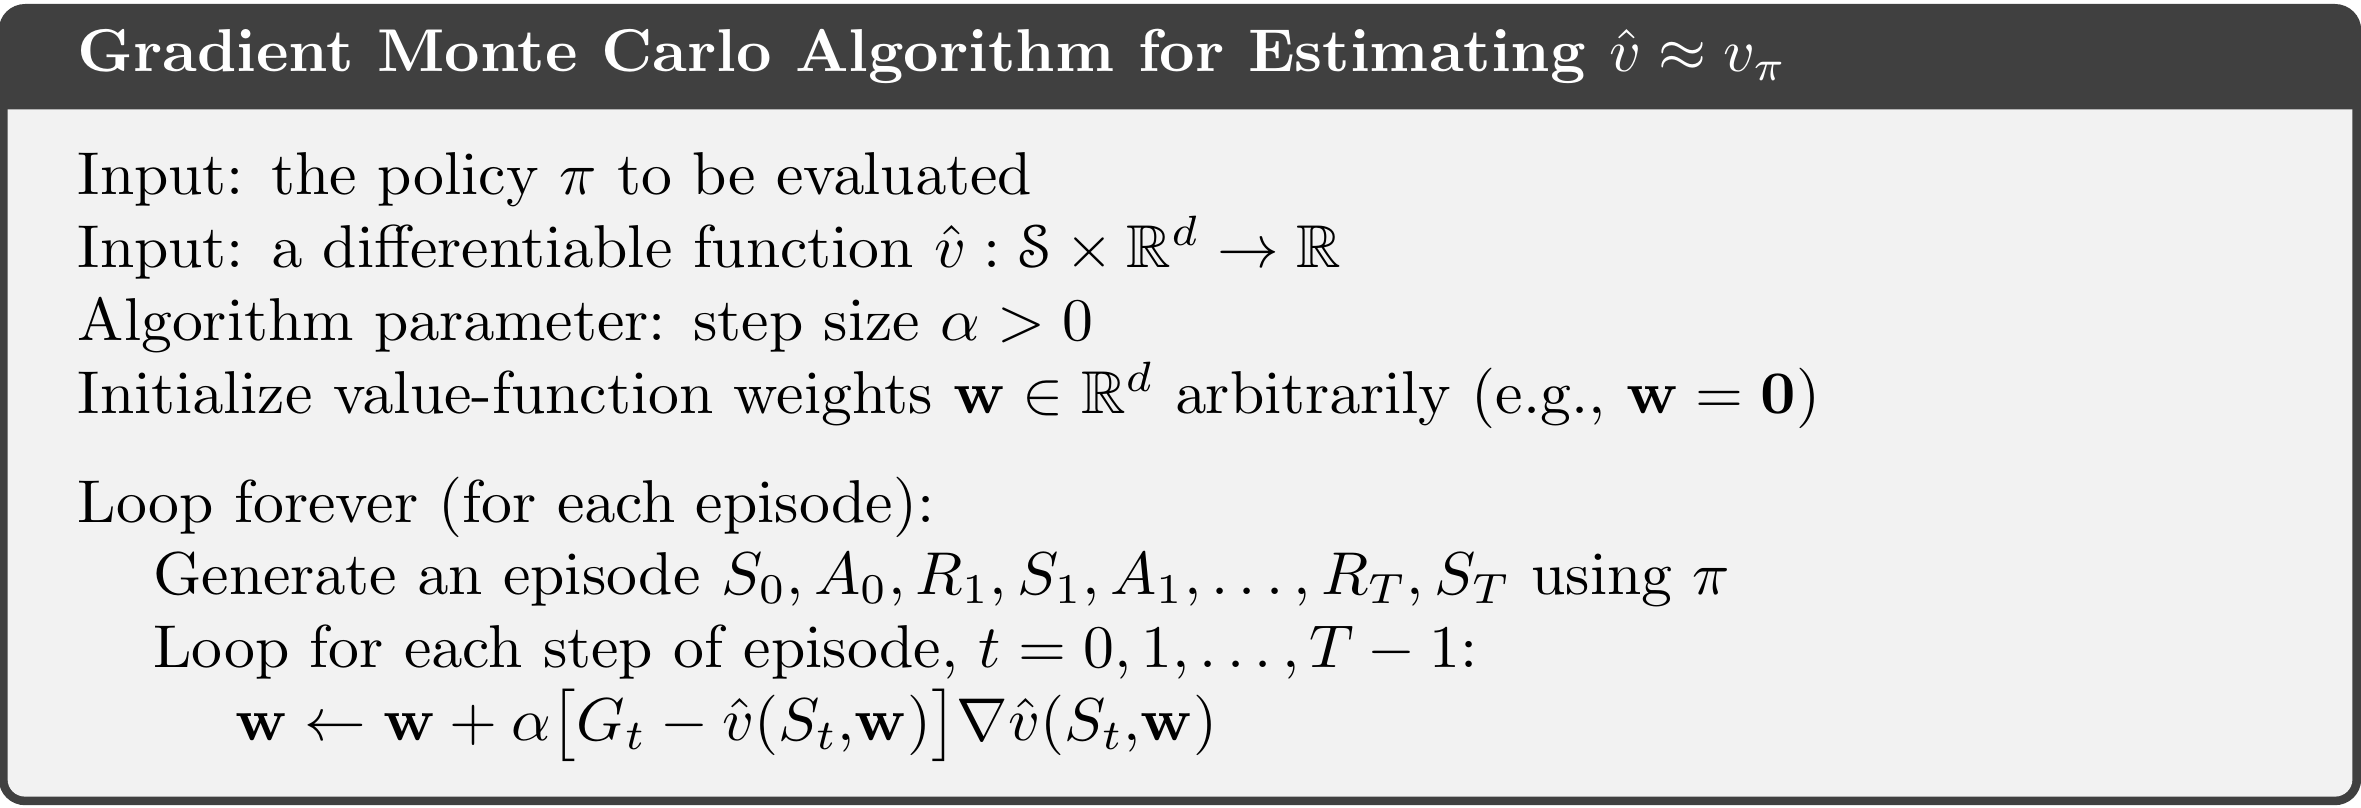


(Repr. de Sutton e Barto 2002 (cap. 9))

A idéia é aplicar uma *atualização* ao vetor de parâmetros $W$.

Ao final de um episódio, é possível listar todos os estados $S_0, \ldots, S_n$ e uma sequência de retornos $G_0, \ldots, G_n$.

Seja um par de estado $S_t$ e retorno $G_t$.

Existe uma *diferença* entre o valor do retorno realmente observado e o valor estimado, dada por $\left(G_t - \hat{v}(S_t,W)\right)$.

Nós podemos usar essa diferença e o *gradiente* da função $\nabla_W \hat{v}(S,W)$ para *corrigir* o vetor $W$ de forma a aproximar o valor estimado $\hat{v}(S_t,W)$ do valor realmente observado $G_t$.

Esta correção, no método dos semi-gradientes, é:

\begin{equation}
W \leftarrow w + \alpha \left(G_t - \hat{v}(S_t, W)\right) \nabla_w \hat{v}(S_t, W)
\end{equation}

onde $\alpha$ é a *taxa de aprendizado*, um parâmetro do algoritmo.

No caso do jogo de Othello, assim como no jogo-da-velha, os jogadores se alternam.
Como o jogador busca a jogada que *maximiza* o valor do tabuleiro *após* sua jogada, serão *estes* os estados $S_t$ usados (os ditos "pós-estados).
As configurações dos tabuleiros após a jogada do *oponente* serão ignoradas.


Note que no nosso caso, $\hat{v}(S, W) = \tanh(p \sum_i s_i, w_i)$, onde o índice $i$ varre todas as posições possíveis.

Ora, mas nesse caso,

\begin{equation}
\nabla_W v(S_t, W)  = p(1- \hat{v}(S_t, W_t)^2)T(S_t)
\end{equation}

e o vetor $T(S_t) = \{t_0, \ldots, t_n\}$ é um vetor com 10 componentes (uma para cada peso) que depende do estado do tabuleiro.

A sua $k$-gésima componente é a soma dos valores (-1, 0 ou 1) de todas as posições do tabuleiro que possuem o coeficiente $k$ (vide a definição da variável ```coordenadas_com_coeficiente``` acima).

### Exercício:

Complete a classe ```JogadorAprendizadoMonteCarlo``` abaixo:
Esta classe implementa um jogador que aprende pelo método de Monte Carlo.

Esta classe, assim como a do jogador ```JogadorTabelaPosicoes``` recebe uma tabela de pesos em posições.
Ao contrário desta classe, no entanto, esta classe deve *atualizar* esta tabela após uma partida com o método descrito acima.

A classe usa uma política "$\epsilon$-gulosa", na qual a cada jogada, com probabilidade $\epsilon$ ela escolha uma jogada puramente aleatória e com probabilidade $(1-\epsilon)$ ela escolhe a melhor jogada de acordo com a tabela de pesos.

A chamada ao método ```informa_propria_jogada``` adiciona o estado do jogo *após* a jogada (passado no parâmetro ```tabuleiro_depois```) à lista ```_posicoes```.

A chamada ao método ```informa_fim``` determina o retorno do episódio (-1 se perdeu, 1 se ganhou e 0 se empatou) e percorre as posições na lista ```_posicoes``` de trás para frente e a cada posição aplica uma atualização na tabela de pesos, armazenada no atributo ```_tabela```. Isso é feito através da chamada ao método ```_ajusta_tabela(self, jogo, retorno)```.

Este método, que você deve completar, modifica a tabela armazenada no atributo ```_tabela``` de acordo com o descrito acima. O parâmetro ```jogo``` contém um objeto da classe ```Othello``` com o estado do tabuleiro $S_t$ e o parâmetro ```retorno``` contém o retorno correspondete ```G_t```.
O parâmetro $\alpha$ está armazenado no atributo ```_alpha```.

*Sugestões*:

*   Observe que o método ```_avalia_posicao(self, jogo)``` calcula $\hat{v}(S_t, W)$. O parâmetro ```jogo``` recebe o estado $S_t$ e o vetor $W$ está armazenado no atributo ```_tabela```.
*   Use o atributo ```_coordenadas_com_coeficientes``` para calcular o vetor $T$.


In [21]:
class JogadorAprendizadoMonteCarlo():
  def __init__(self, indice_coeficientes, coordenadas_com_coeficiente, tabela, alpha, gamma, epsilon):
    self._lins = len(indice_coeficientes)
    self._cols = len(indice_coeficientes[0])
    self._idxcoef = indice_coeficientes
    self._tabela = tabela
    self._gamma = gamma
    self._alpha = alpha
    self._epsilon = epsilon
    self._coordenadas_com_coeficiente = coordenadas_com_coeficiente

  def _valor_pesos(self, jogo):
    val = 0.0
    for i in range(self._lins):
      for j in range(self._cols):
        val += jogo.posicao((i,j))*self._tabela[self._idxcoef[i][j]]
    return val*self._jogador

  # Tangente hiperbólica, mantém o valor entre -1 e 1
  def _avalia_posicao(self, jogo):
    return 2/(1+np.exp(-2*self._valor_pesos(jogo)))-1

  def _avalia_jogada(self, jogo, jogada):
    return self._avalia_posicao(jogo.joga(jogada))

  def _ajusta_tabela(self, jogo, retorno):
    # Calculate estimated value V_hat(S_t, W)
    valor_posicao_estimado = self._avalia_posicao(jogo)

    # Calculate the error (G_t - V_hat(S_t, W))
    erro = retorno - valor_posicao_estimado

    # Calculate the T(S_t) vector for gradient computation
    # T_k is the sum of state values (s_i) for all positions corresponding to coefficient k
    T_vector = np.zeros(len(self._tabela))
    for k in range(len(self._tabela)): # Iterate through each coefficient index (0 to 9)
        for r, c in self._coordenadas_com_coeficiente[k]:
            T_vector[k] += jogo.posicao((r, c))

    # Apply the update rule: W <- W + alpha * (G_t - V_hat) * gradient_V_hat
    # gradient_V_hat = p * (1 - V_hat^2) * T_k
    for k in range(len(self._tabela)):
        gradient_component_k = self._jogador * (1 - valor_posicao_estimado**2) * T_vector[k]
        self._tabela[k] += self._alpha * erro * gradient_component_k


  def nova_partida(self, jogo, jogador):
    self._posicoes = []
    self._jogador = jogador

  def escolhe_jogada(self, jogo):
    jogadas_possiveis = jogo.jogadas_legais()
    if np.random.rand()<self._epsilon:
      idx = np.random.choice(len(jogadas_possiveis))
    else:
      valores = [self._avalia_jogada(jogo, jogada) for jogada in jogadas_possiveis]
      idx = np.argmax(valores)
    return jogadas_possiveis[idx]

  def informa_propria_jogada(self, tabuleiro_antes, jogada, tabuleiro_depois):
    self._posicoes.append(tabuleiro_depois)

  def informa_jogada_oponente(self, tabuleiro_antes, jogada, tabuleiro_depois):
    pass

  def informa_fim(self, jogo_final):
    placar_proprio = jogo_final.placar(self._jogador)
    if placar_proprio>32:
      resultado = 1
    elif placar_proprio<32:
      resultado = -1
    else:
      resultado = 0
    for p in reversed(self._posicoes):
      self._ajusta_tabela(p, resultado)
      resultado *= self._gamma


Treine os jogadores colocando-os para jogar entre si:

In [22]:
tabela_mc_primeiro_jogador = [1.0]*10 # Inicializa com tabela unitária
tabela_mc_segundo_jogador = [1.0]*10
jogador1 = JogadorAprendizadoMonteCarlo(indice_coeficientes, coordenadas_com_coeficiente, tabela_mc_primeiro_jogador, 0.02, 1.0, 0.1)
jogador2 = JogadorAprendizadoMonteCarlo(indice_coeficientes, coordenadas_com_coeficiente, tabela_mc_segundo_jogador, 0.02, 1.0, 0.1)
partidas = 1000
progresso = widgets.IntProgress(min=0, max=partidas)
display(progresso)
for i in range(partidas):
  jogo = Othello()
  simula_partida(jogo, jogador1, jogador2)
  progresso.value=i

IntProgress(value=0, max=1000)

Esta classe deve vencer aproximadamente 65\% das partidas contra um jogador aleatório (talvez um pouco mais):

In [23]:
empates = 0
vitorias = 0
derrotas = 0
partidas = 200
progresso = widgets.IntProgress(min=0, max=partidas)
display(progresso)
for i in range(partidas):
  jogo = Othello()
  resultado = simula_partida(Othello(), JogadorTabelaPosicoes(indice_coeficientes, coordenadas_com_coeficiente, tabela_mc_primeiro_jogador),  JogadorAleatorio())
  if resultado.placar(1)>32:
    vitorias += 1
  elif resultado.placar(1)<32:
    derrotas += 1
  else:
    empates+=1
  progresso.value=i
print("Aprendizado de Monte Carlo, 1o jogador")
print(f"Vitórias: {100*vitorias/partidas}%")
print(f"Derrotas: {100*derrotas/partidas}%")
print(f"Empates: {100*empates/partidas}%")

IntProgress(value=0, max=200)

Aprendizado de Monte Carlo, 1o jogador
Vitórias: 68.5%
Derrotas: 28.5%
Empates: 3.0%


## 1.3 Aprendizado por diferenças temporais (TD)

Assim como no aprendizado de Monte Carlo, há uma versão do algoritmo de TD para métodos aproximados.

Segue-se uma reprodução do algoritmo retirada do capítulo 9 de "Reinforcement Learning, an introduction" (2nd ed.):

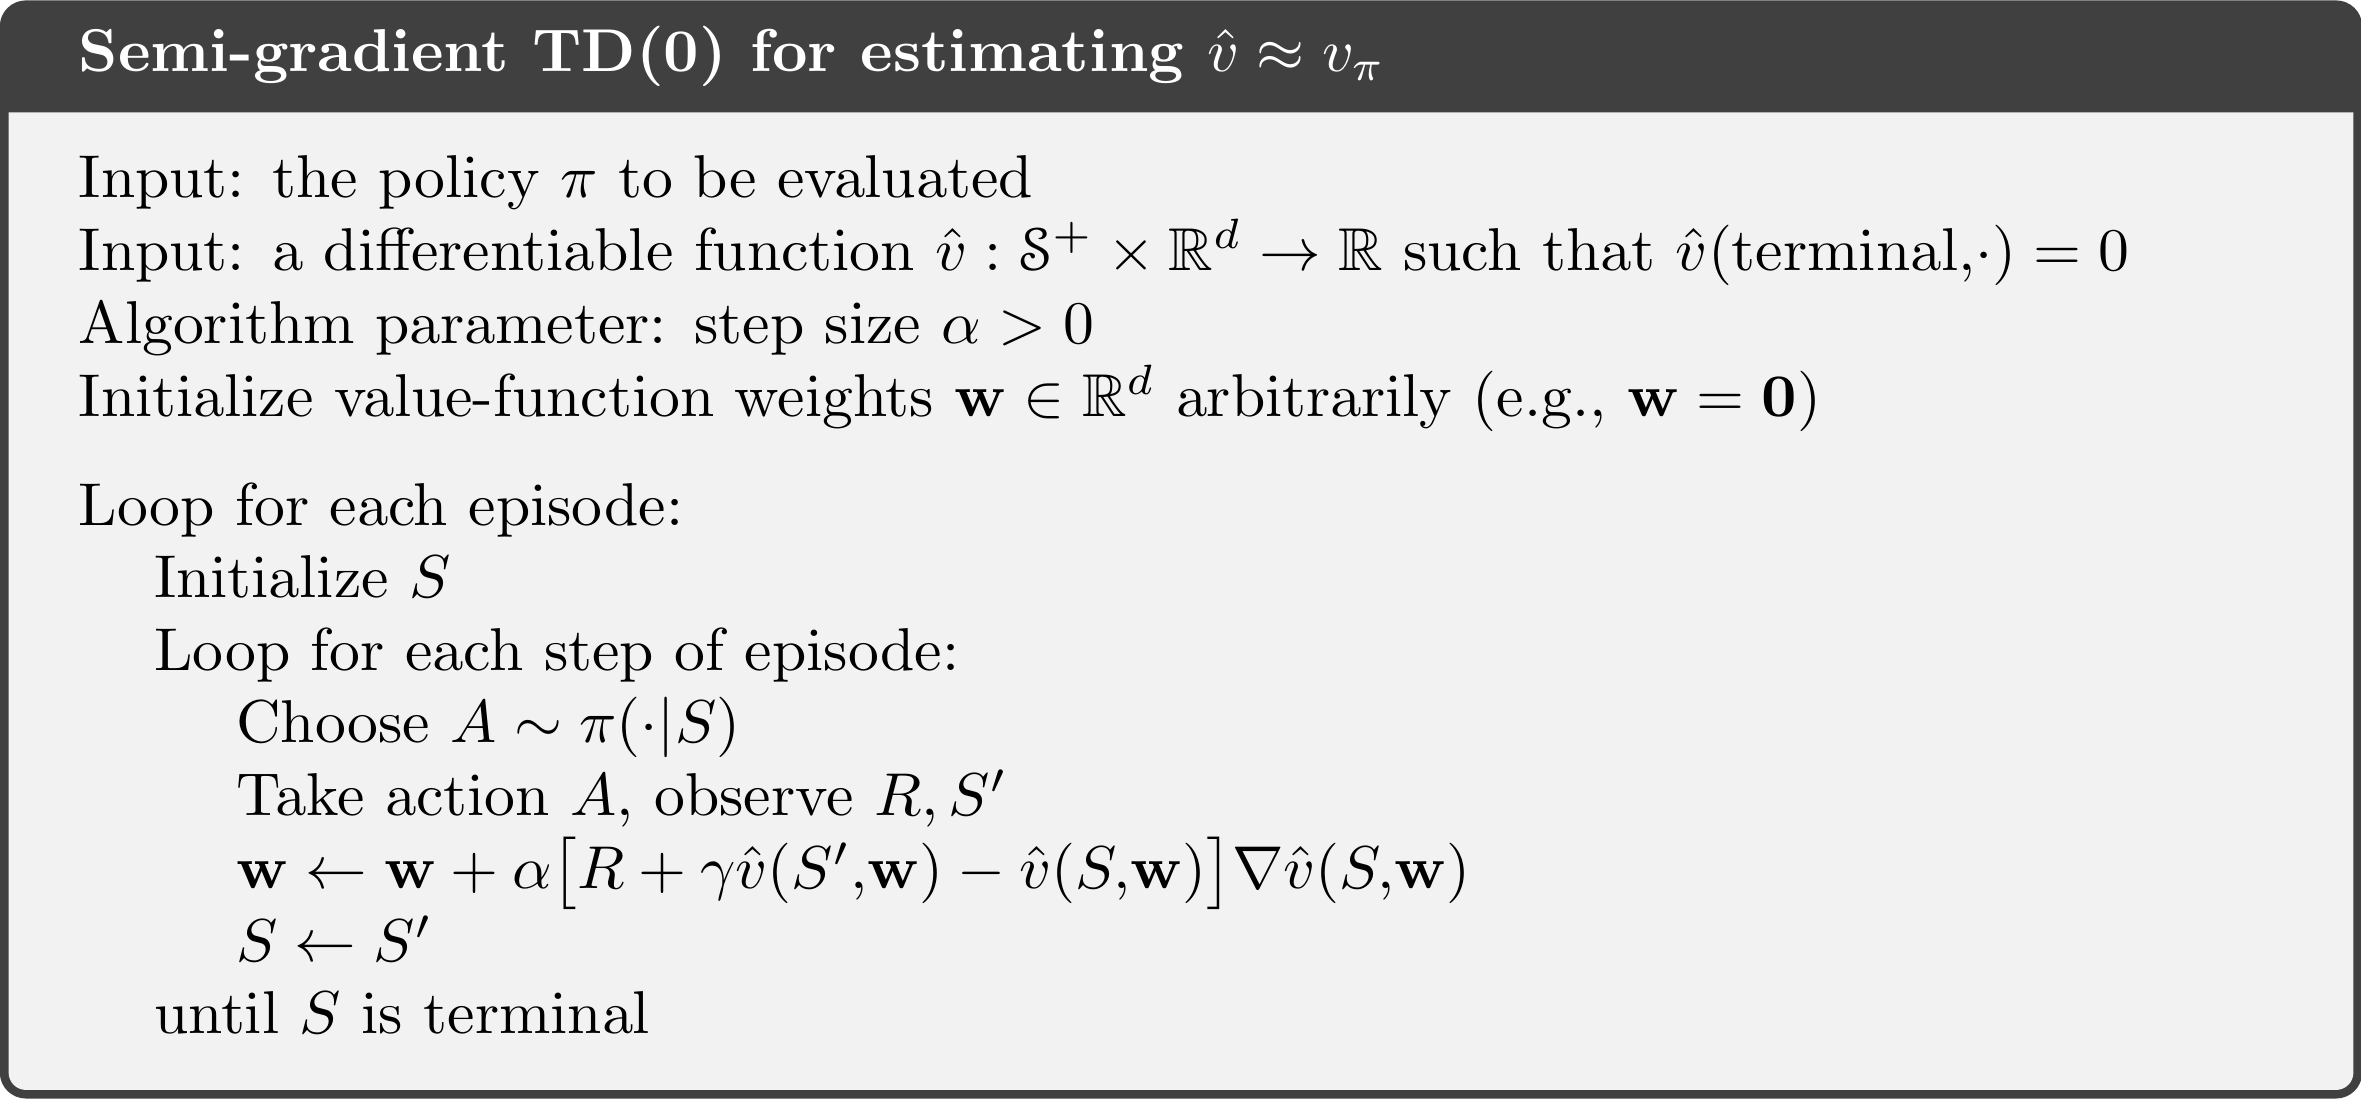

(Repr. de Sutton e Barto 2002, cap. 9)

Assim como no método de Monte Carlo, a idéia é novamente aplicar uma *correção* no vetor de pesos.

No método das diferenças temporais, observa-se uma transição de um estado $S$ para um estado $S'$, com recompensa $R$.

Nesta caso, pela definição, espera-se que o valor do estado $S$, dado por $v(S')$, aproxime-se de $(R+ \gamma v(S'))$.

Seja $\hat{v}(S, W)$ a função aproximadora para o valor do estado.

Nesta caso, define-se a diferença entre o valor observado e o estimado durante a transição de $S'$ para S como:

\begin{equation}
R+\gamma \hat{v}(S', W) - \hat{v}(S, W)
\end{equation}

Do mesmo modo, podemos usar um método de semi-gradientes para atualizar o vetor $W$ *a cada passo* do jogo:

\begin{equation}
W \leftarrow W + \alpha \left(R+\gamma \hat{v}(S', W) - \hat{v}(S, W)\right)\nabla_W \hat{v}(S,W)
\end{equation}

Novamente, $\alpha$ é a taxa de aprendizado.


### Exercício:

Complete a classe ```JogadorAprendizadoTD```.

Esta classe é similar à classe ```JogadorAprendizadoMonteCarlo``` descrita acima, no sentido de que ela atualiza a tabela de coeficientes passada a ela no seu construtor.

Assim como na classe ```JogadorAprendizadoMonteCarlo```, ela explora o espaço das jogadas com uma política $\epsilon$-gulosa.

Ela mantém o registro da última posição jogada no atributo ```_estado_anterior```.
A chamada ao método ```informa_jogada_propria``` recebe um novo "pós-estado" no parâmetro ```tabuleiro_depois```.
Se há um estado anterior no atributo ```_estado_anterior```, é chamado o método ```_ajusta_tabela_td(self, estado_antes, estado_depois, recompensa)```.

Você deve completar este método.
O parâmetro ```estado_antes```  recebe o estado $S$, o parâmetro ```estado_depois```  recebe o estado $S'$ e o parâmetro ```recompensa``` recebe a recompensa $R$ (no caso do jogo Othello, ela é sempre nula em transições não-finais). Você deve modificar a tabela de pesos armazenada no atributo ```_tabela_treinada```.

Você também deve completar a implementação da função ```informa_fim(self, jogo_final)```.
Note que pela definição do TD, é necessário fazer uma *última* atualização no vetor de pesos.

*Sugestões*:
* Observe que a classe TD usa *duas* tabelas de coeficientes. Uma é usada para escolher a próxima jogada, outra é *atualizada*. A tabela de escolha de jogada está no atributo ```_tabela_avaliada``` e *não* deve ser modificada pelo treinamento (ela é copiada da ```_tabela_treinada``` ao início de uma nova partida).

*   Você deve ter implementado o método ```_ajusta_tabela``` na classe ```JogadorAprendizadoMonteCarlo```. Este método é útil aqui?



In [25]:
class JogadorAprendizadoTD():
  def __init__(self, indice_coeficientes, coordenadas_com_coeficiente, tabela, alpha, gamma, epsilon):
    self._lins = len(indice_coeficientes)
    self._cols = len(indice_coeficientes[0])
    self._idxcoef = indice_coeficientes
    self._coordenadas_com_coeficiente = coordenadas_com_coeficiente
    self._tabela_treinada = tabela
    self._gamma = gamma
    self._alpha = alpha
    self._epsilon = epsilon

  def _valor_pesos(self, jogo, tabela):
    val = 0.0
    for i in range(self._lins):
      for j in range(self._cols):
        val += jogo.posicao((i,j))*self._jogador*tabela[self._idxcoef[i][j]]
    return val

  def _avalia_posicao(self, jogo, tabela):
    return 2/(1+np.exp(-2*self._valor_pesos(jogo, tabela)))-1

  def _avalia_jogada(self, jogo, jogada, tabela):
    return self._avalia_posicao(jogo.joga(jogada), tabela)

  def _ajusta_tabela_td(self, estado_antes, estado_depois, recompensa):
    # Calculate estimated value V_hat(S, W)
    valor_posicao_estimado_antes = self._avalia_posicao(estado_antes, self._tabela_treinada)

    # Calculate estimated value V_hat(S', W)
    valor_posicao_estimado_depois = self._avalia_posicao(estado_depois, self._tabela_treinada)

    # Calculate the TD error: delta = R + gamma * V_hat(S', W) - V_hat(S, W)
    td_erro = recompensa + self._gamma * valor_posicao_estimado_depois - valor_posicao_estimado_antes

    # Calculate the T(S) vector for gradient computation for estado_antes
    T_vector_antes = np.zeros(len(self._tabela_treinada))
    for k in range(len(self._tabela_treinada)):
        for r, c in self._coordenadas_com_coeficiente[k]:
            T_vector_antes[k] += estado_antes.posicao((r, c))

    # Apply the update rule: W <- W + alpha * delta * gradient_V_hat(S,W)
    # gradient_V_hat(S,W)_k = p * (1 - V_hat(S,W)^2) * T_k(S)
    for k in range(len(self._tabela_treinada)):
        gradient_component_k = self._jogador * (1 - valor_posicao_estimado_antes**2) * T_vector_antes[k]
        self._tabela_treinada[k] += self._alpha * td_erro * gradient_component_k


  def nova_partida(self, jogo, jogador):
    self._estado_anterior = None
    self._jogador = jogador
    # TD "Clássico" não modifca a função v durante um episódio
    self._tabela_avaliada = list(self._tabela_treinada)

  def escolhe_jogada(self, jogo):
    jogadas_possiveis = jogo.jogadas_legais()
    if np.random.rand()<self._epsilon:
      idx = np.random.choice(len(jogadas_possiveis))
    else:
      valores = [self._avalia_jogada(jogo, jogada, self._tabela_avaliada) for jogada in jogadas_possiveis]
      idx = np.argmax(valores)
    return jogadas_possiveis[idx]

  def informa_propria_jogada(self, tabuleiro_antes, jogada, tabuleiro_depois):
    if self._estado_anterior:
      # Ajusta pesos
      self._ajusta_tabela_td(self._estado_anterior, tabuleiro_depois, 0)
    # Atualiza _estado_anterior
    self._estado_anterior = tabuleiro_depois

  def informa_jogada_oponente(self, tabuleiro_antes, jogada, tabuleiro_depois):
    pass

  def informa_fim(self, jogo_final):
    placar_proprio = jogo_final.placar(self._jogador)
    if placar_proprio>32:
      resultado = 1
    elif placar_proprio<32:
      resultado = -1
    else:
      resultado = 0
    # A última atualização é necessária para o estado anterior e a recompensa final
    if self._estado_anterior:
        # Calculate estimated value V_hat(S, W) for the last non-terminal state
        valor_posicao_estimado_antes = self._avalia_posicao(self._estado_anterior, self._tabela_treinada)

        # For terminal state S', V(S') is 0. So, td_erro = R + gamma * 0 - V_hat(S, W)
        td_erro = resultado + self._gamma * 0 - valor_posicao_estimado_antes

        # Calculate the T(S) vector for gradient computation for the last non-terminal state
        T_vector_antes = np.zeros(len(self._tabela_treinada))
        for k in range(len(self._tabela_treinada)):
            for r, c in self._coordenadas_com_coeficiente[k]:
                T_vector_antes[k] += self._estado_anterior.posicao((r, c))

        # Apply the final update rule
        for k in range(len(self._tabela_treinada)):
            gradient_component_k = self._jogador * (1 - valor_posicao_estimado_antes**2) * T_vector_antes[k]
            self._tabela_treinada[k] += self._alpha * td_erro * gradient_component_k


Treine um jogador com 500 iterações: O método TD é um método de *bootstraping*, ou seja, ele precisa de uma estimativa inicial. Vamos usar a tabela unitária.

In [26]:
# Bootstrap com tabela unitária
tabela_td_primeiro_jogador = list(tabela_unitaria)
tabela_td_segundo_jogador = list(tabela_unitaria)
jogador1 = JogadorAprendizadoTD(indice_coeficientes, coordenadas_com_coeficiente, tabela_td_primeiro_jogador, 0.01, 1.0, 0.1)
jogador2 = JogadorAprendizadoTD(indice_coeficientes, coordenadas_com_coeficiente, tabela_td_segundo_jogador, 0.01, 1.0, 0.1)
partidas = 500
progresso = widgets.IntProgress(min=0, max=partidas)
display(progresso)
for i in range(partidas):
  jogo = Othello()
  simula_partida(jogo, jogador1, jogador2)
  progresso.value=i

IntProgress(value=0, max=500)

Vamos avaliar a estratégia contra um jogador aleatório.
O desempenho deve ser próximo do obtido pelo jogador de Monte Carlo (talvez um pouco inferior):

In [27]:
empates = 0
vitorias = 0
derrotas = 0
partidas = 200
progresso = widgets.IntProgress(min=0, max=partidas)
display(progresso)
for i in range(partidas):
  jogo = Othello()
  resultado = simula_partida(Othello(), JogadorTabelaPosicoes(indice_coeficientes, coordenadas_com_coeficiente, tabela_td_primeiro_jogador),  JogadorAleatorio())
  if resultado.placar(1)>32:
    vitorias += 1
  elif resultado.placar(1)<32:
    derrotas += 1
  else:
    empates+=1
  progresso.value=i
print("Aprendizado por TD, 1o jogador")
print(f"Vitórias: {100*vitorias/partidas}%")
print(f"Derrotas: {100*derrotas/partidas}%")
print(f"Empates: {100*empates/partidas}%")

IntProgress(value=0, max=200)

Aprendizado por TD, 1o jogador
Vitórias: 64.0%
Derrotas: 34.0%
Empates: 2.0%


Há uma questão no entanto: A política avaliada é uma política "$\epsilon$-gulosa", enquanto que a efetivamente executada (pelo ```JogadorTabelaPosicoes```) é uma política totalmente gulosa.

Lembre-se no entanto que o TD é um método de *bootstraping*! Podemos aproveitar o resultado anterior e avaliar uma nova política baixando-se o parâmetro $\epsilon$ e aproximando-nos da política realmente executada na avaliação:

In [28]:
# Bootstrap com resultado_anterior
tabela_td_primeiro_jogador_2 = list(tabela_td_primeiro_jogador)
tabela_td_segundo_jogador_2 = list(tabela_td_primeiro_jogador)
jogador1 = JogadorAprendizadoTD(indice_coeficientes, coordenadas_com_coeficiente, tabela_td_primeiro_jogador_2, 0.005, 1.0, 0.01)
jogador2 = JogadorAprendizadoTD(indice_coeficientes, coordenadas_com_coeficiente, tabela_td_segundo_jogador_2, 0.005, 1.0, 0.01)
partidas = 500
progresso = widgets.IntProgress(min=0, max=partidas)
display(progresso)
for i in range(partidas):
  jogo = Othello()
  simula_partida(jogo, jogador1, jogador2)
  progresso.value=i

IntProgress(value=0, max=500)

A nova política deve ser um pouco melhor:

In [29]:
empates = 0
vitorias = 0
derrotas = 0
partidas = 400
progresso = widgets.IntProgress(min=0, max=partidas)
display(progresso)
for i in range(partidas):
  jogo = Othello()
  resultado = simula_partida(Othello(), JogadorTabelaPosicoes(indice_coeficientes, coordenadas_com_coeficiente, tabela_td_primeiro_jogador_2),  JogadorAleatorio())
  if resultado.placar(1)>32:
    vitorias += 1
  elif resultado.placar(1)<32:
    derrotas += 1
  else:
    empates+=1
  progresso.value=i
print("Aprendizado por TD, 1o jogador")
print(f"Vitórias: {100*vitorias/partidas}%")
print(f"Derrotas: {100*derrotas/partidas}%")
print(f"Empates: {100*empates/partidas}%")

IntProgress(value=0, max=400)

Aprendizado por TD, 1o jogador
Vitórias: 83.75%
Derrotas: 13.75%
Empates: 2.5%


Tente você mesmo jogar contra o jogador que acaba de treinar.
Você deve achar o novo jogador mais desafiante:

In [34]:
partida_interativa_ai(Othello(), JogadorTabelaPosicoes(indice_coeficientes, coordenadas_com_coeficiente, tabela_td_segundo_jogador_2))

### 1.4 Aprendizado TD($\lambda$)

O algoritmo TD($\lambda$) estende o método de Diferenças Temporais (TD) através do uso de **traços de elegibilidade** ($E$). Enquanto o TD(0) atualiza apenas o estado imediatamente anterior, o TD($\lambda$) combina as vantagens de Diferenças Temporais e Monte Carlo, permitindo que uma recompensa ou erro atual influencie uma sequência de estados visitados anteriormente.

#### Traços de Elegibilidade

O vetor de traços de elegibilidade $e_t$ tem a mesma dimensão que o vetor de pesos $W$ e é atualizado a cada passo:


$e_t = \gamma \lambda e_{t-1} + \nabla_W \hat{v}(S_t, W)$

Onde:
*   $\gamma$ é o fator de desconto.
*   $\lambda \in [0, 1]$ define o quão rápido o traço decai.
*   $\nabla_W \hat{v}(S_t, W)$ é o gradiente da função de aproximação (no nosso modelo, a derivada da tangente hiperbólica multiplicada pelo vetor de simetrias $T$).

#### Regra de Atualização

A atualização dos parâmetros $W$ ocorre a cada transição baseada no erro TD ($\delta$):

$\delta = R + \gamma \hat{v}(S', W) - \hat{v}(S, W)$

$W \leftarrow W + \alpha \delta e_t$



Segue-se uma reprodução do algoritmo $TD(\lambda)$ reproduzida do capítulo 9 de Sutton e Barto:

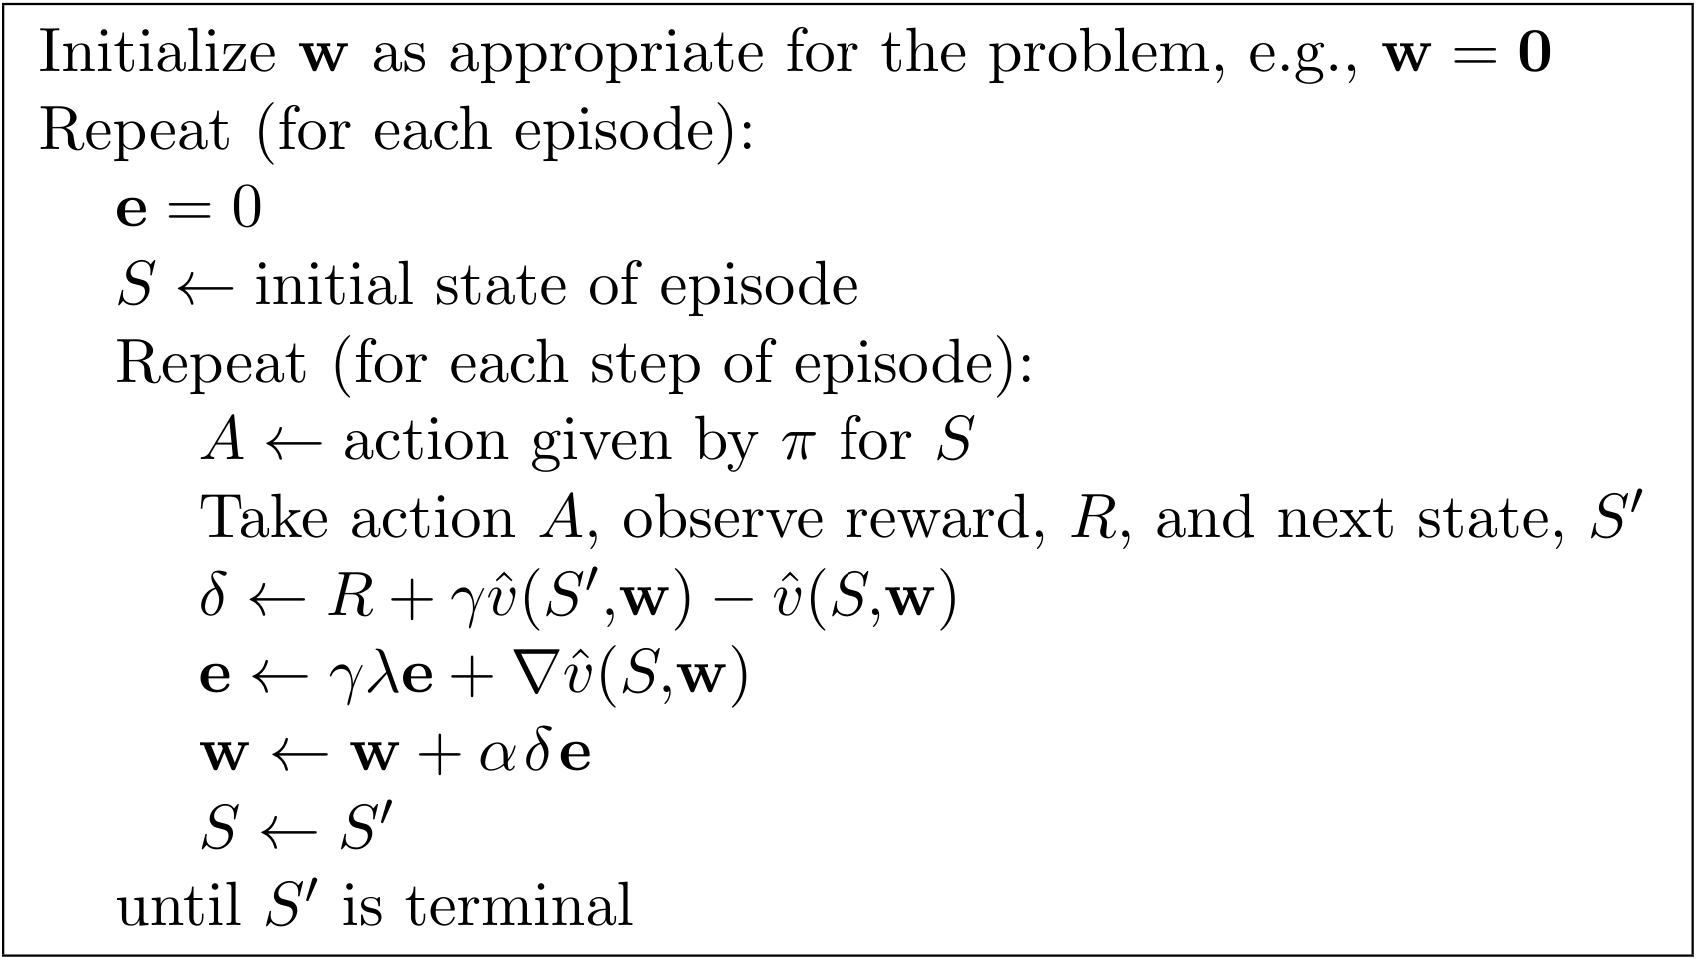

(Repr. de Sutton e Barto 2002, cap. 9)

### Exercício

Complete a classe ```JogadorAprendizadoTD_l```.

Esta classe é similar à classe ```JogadorAprendizadoTD``` que você completou acima.

Agora ela incorpora também o *vetor de traços de eligibilidade* em ```self._e```.
Este vetor é zerado a cada nova partida.

A cada passo você deve atualizar este vetor e utilizá-lo para ajustar a tabela de pesos como no algoritmo acima.

In [31]:
class JogadorAprendizadoTD_l():
  def __init__(self, indice_coeficientes, coordenadas_com_coeficiente, tabela, alpha, gamma, lbda, epsilon):
    self._lins = len(indice_coeficientes)
    self._cols = len(indice_coeficientes[0])
    self._idxcoef = indice_coeficientes
    self._coordenadas_com_coeficiente = coordenadas_com_coeficiente
    self._tabela_treinada = tabela
    self._gamma = gamma
    self._alpha = alpha
    self._lbda = lbda
    self._epsilon = epsilon

  def _valor_pesos(self, jogo, tabela):
    val = 0.0
    for i in range(self._lins):
      for j in range(self._cols):
        val += jogo.posicao((i,j))*self._jogador*tabela[self._idxcoef[i][j]]
    return val

  def _avalia_posicao(self, jogo, tabela):
    return 2/(1+np.exp(-2*self._valor_pesos(jogo, tabela)))-1

  def _avalia_jogada(self, jogo, jogada, tabela):
    return self._avalia_posicao(jogo.joga(jogada), tabela)

  def _ajusta_tabela_td(self, estado_antes, estado_depois, recompensa):
    # Calculate estimated value V_hat(S, W)
    valor_posicao_estimado_antes = self._avalia_posicao(estado_antes, self._tabela_treinada)

    # Calculate estimated value V_hat(S', W)
    valor_posicao_estimado_depois = self._avalia_posicao(estado_depois, self._tabela_treinada)

    # Calculate the TD error: delta = R + gamma * V_hat(S', W) - V_hat(S, W)
    td_erro = recompensa + self._gamma * valor_posicao_estimado_depois - valor_posicao_estimado_antes

    # Calculate the T(S) vector for gradient computation for estado_antes
    T_vector_antes = np.zeros(len(self._tabela_treinada))
    for k in range(len(self._tabela_treinada)):
        for r, c in self._coordenadas_com_coeficiente[k]:
            T_vector_antes[k] += estado_antes.posicao((r, c))

    # Calculate gradient of V_hat(S, W)
    gradient_V_hat_antes_vector = np.array([self._jogador * (1 - valor_posicao_estimado_antes**2) * T_vector_antes[k] for k in range(len(self._tabela_treinada))])

    # Update eligibility traces: E <- gamma * lambda * E + grad_V_hat(S, W)
    self._e = self._gamma * self._lbda * self._e + gradient_V_hat_antes_vector

    # Update weights: W <- W + alpha * delta * E
    self._tabela_treinada += self._alpha * td_erro * self._e


  def nova_partida(self, jogo, jogador):
    self._estado_anterior = None
    self._jogador = jogador
    # Inicializa vetor de traços de eligibilidade
    self._e = np.zeros(len(self._tabela_treinada))
    # TD "Clássico" não modifca a função v durante um episódio
    self._tabela_avaliada = list(self._tabela_treinada)

  def escolhe_jogada(self, jogo):
    jogadas_possiveis = jogo.jogadas_legais()
    if np.random.rand()<self._epsilon:
      idx = np.random.choice(len(jogadas_possiveis))
    else:
      valores = [self._avalia_jogada(jogo, jogada, self._tabela_avaliada) for jogada in jogadas_possiveis]
      idx = np.argmax(valores)
    return jogadas_possiveis[idx]

  def informa_propria_jogada(self, tabuleiro_antes, jogada, tabuleiro_depois):
    if self._estado_anterior:
      # Ajusta pesos
      self._ajusta_tabela_td(self._estado_anterior, tabuleiro_depois, 0)
    # Atualiza _estado_anterior
    self._estado_anterior = tabuleiro_depois

  def informa_jogada_oponente(self, tabuleiro_antes, jogada, tabuleiro_depois):
    pass

  def informa_fim(self, jogo_final):
    placar_proprio = jogo_final.placar(self._jogador)
    if placar_proprio>32:
      resultado = 1
    elif placar_proprio<32:
      resultado = -1
    else:
      resultado = 0
    # A última atualização é necessária para o estado anterior e a recompensa final
    if self._estado_anterior:
        # Calculate estimated value V_hat(S, W) for the last non-terminal state (self._estado_anterior)
        valor_posicao_estimado_antes = self._avalia_posicao(self._estado_anterior, self._tabela_treinada)

        # For terminal state S', V(S') is 0. So, td_erro = R + gamma * 0 - V_hat(S, W)
        td_erro = resultado + self._gamma * 0 - valor_posicao_estimado_antes

        # Calculate the T(S) vector for gradient computation for the last non-terminal state
        T_vector_antes = np.zeros(len(self._tabela_treinada))
        for k in range(len(self._tabela_treinada)):
            for r, c in self._coordenadas_com_coeficiente[k]:
                T_vector_antes[k] += self._estado_anterior.posicao((r, c))

        # Calculate gradient of V_hat(S, W) for the last non-terminal state
        gradient_V_hat_antes_vector = np.array([self._jogador * (1 - valor_posicao_estimado_antes**2) * T_vector_antes[k] for k in range(len(self._tabela_treinada))])

        # Update eligibility traces one last time with the gradient of the last non-terminal state
        self._e = self._gamma * self._lbda * self._e + gradient_V_hat_antes_vector

        # Apply the final update rule for weights
        self._tabela_treinada += self._alpha * td_erro * self._e


Treine o seu agente usando como ponto de partida as tabelas do agente anterior:

In [32]:
# Bootstrap com resultado_anterior
tabela_td_primeiro_jogador_3 = list(tabela_td_primeiro_jogador_2)
tabela_td_segundo_jogador_3 = list(tabela_td_primeiro_jogador_2)
jogador1 = JogadorAprendizadoTD_l(indice_coeficientes, coordenadas_com_coeficiente, tabela_td_primeiro_jogador_3, 0.004, 1.0, 0.7, 0.006)
jogador2 = JogadorAprendizadoTD_l(indice_coeficientes, coordenadas_com_coeficiente, tabela_td_segundo_jogador_3, 0.004, 1.0, 0.7, 0.006)
partidas = 700
progresso = widgets.IntProgress(min=0, max=partidas)
display(progresso)
for i in range(partidas):
  jogo = Othello()
  simula_partida(jogo, jogador1, jogador2)
  progresso.value=i

IntProgress(value=0, max=700)

Com um pouco de sorte, este deve ser o melhor desempenho até agora

In [33]:
empates = 0
vitorias = 0
derrotas = 0
partidas = 600
progresso = widgets.IntProgress(min=0, max=partidas)
display(progresso)
for i in range(partidas):
  jogo = Othello()
  resultado = simula_partida(Othello(), JogadorTabelaPosicoes(indice_coeficientes, coordenadas_com_coeficiente, tabela_td_primeiro_jogador_3),  JogadorAleatorio())
  if resultado.placar(1)>32:
    vitorias += 1
  elif resultado.placar(1)<32:
    derrotas += 1
  else:
    empates+=1
  progresso.value=i
print("Aprendizado por TD(λ), 1o jogador")
print(f"Vitórias: {100*vitorias/partidas}%")
print(f"Derrotas: {100*derrotas/partidas}%")
print(f"Empates: {100*empates/partidas}%")

IntProgress(value=0, max=600)

Aprendizado por TD(λ), 1o jogador
Vitórias: 83.83333333333333%
Derrotas: 13.833333333333334%
Empates: 2.3333333333333335%
